# Testing Feature Engineering

I was able to run this code on an SCF cluster node in this jupyter notebook by following the instructions at this link:
https://computing.stat.berkeley.edu/access/vscode-remote-ssh/#connect-to-an-scf-cluster-node

In [17]:
library(tidyverse)
od_data <- read_csv("../data/od-data.csv")

Rows: 67770440 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): origin, destination
dbl  (2): hour, ridership
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Adding Features Mentioned in Previous EDA's

Since were going to be adding columns, let's check the size of the data object now.

In [41]:
format(object.size(od_data), units = "GB")

[1] "4 Gb"

Let's start by adding on the basic features from previous discussions

In [19]:
od_data <- od_data |> mutate(post_covid = if_else(date > ymd("2020-03-19"), 1, 0),
                            day = case_when(wday(date) %in% seq(2, 6) ~ "weekday",
                                            wday(date) == 1 ~ "sunday",
                                            wday(date) == 7 ~ "saturday")
                        )

Let's calculate some basic statistics grouped by our covid indicator and day variable.

In [20]:
od_data |> 
    group_by(post_covid, day) |>
    summarize(count = n(), median = median(ridership), mean = mean(ridership), sd = sd(ridership))

`summarise()` has grouped output by 'post_covid'. You can override using the
`.groups` argument.


post_covid,day,count,median,mean,sd
<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
0,saturday,2842651,3,6.663028,12.622526
0,sunday,2425078,2,5.555799,11.226489
0,weekday,17058977,4,13.353914,35.826595
1,saturday,5692795,2,4.012325,6.665476
1,sunday,4830493,2,3.527505,5.818969
1,weekday,34920446,2,5.523402,10.962697


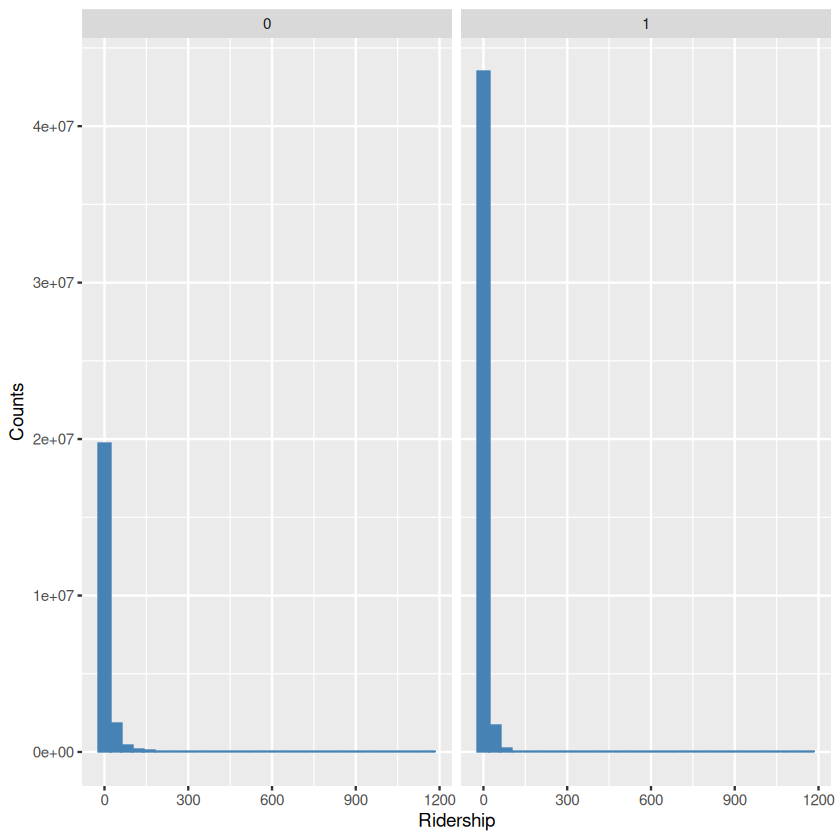

In [21]:
od_data |> 
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

Let's look at the days and OD pairs with the max ridership. The one below is what we saw earlier.

In [22]:
od_data |>
    filter(post_covid == 0) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2018-08-24,23,COLS,DUBL,1165,0,weekday


This one is pretty funny. This is the day a person went into the transbay tube and stopped BART service for over an hour. These are people getting on at Embarcadero, realizing they can't go anywhere, and getting off at the same station.

In [23]:
od_data |>
    filter(post_covid == 1) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2023-11-29,17,EMBR,EMBR,1030,1,weekday


And this one is a No-Kings protest.

In [24]:
od_data |>
    filter(post_covid == 1,
            origin != destination) |>
    slice_max(ridership)

date,hour,origin,destination,ridership,post_covid,day
<date>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2025-10-18,13,24TH,EMBR,944,1,saturday


## More Feature Engineering

Let's do a log transformation of our ridership variable and see what happens to the previous analysis

In [25]:
od_data <- od_data |> mutate(log_ridership = log(ridership))

In [26]:
od_data |> 
    group_by(post_covid, day) |>
    summarize(median = median(log_ridership), mean = mean(log_ridership), sd = sd(log_ridership))

`summarise()` has grouped output by 'post_covid'. You can override using the
`.groups` argument.


post_covid,day,median,mean,sd
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0,saturday,1.0986123,1.1658628,1.0941359
0,sunday,0.6931472,1.0485970,1.0225074
0,weekday,1.3862944,1.4754901,1.3144739
1,saturday,0.6931472,0.8584232,0.9134418
1,sunday,0.6931472,0.7757657,0.8620717
1,weekday,0.6931472,1.0133411,1.0321329


The log transformation does not seem to do much to the ridership data. Also evidenced below in the plot, it's still very right skewed.

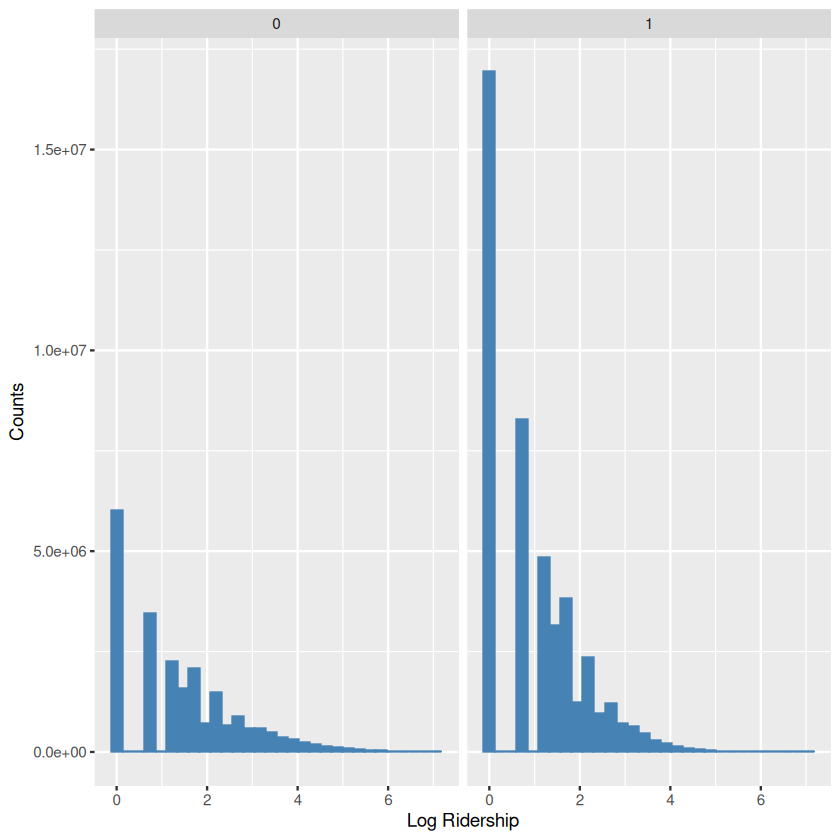

In [27]:
od_data |> 
    ggplot(aes(x = log_ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Log Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

I want to check, now that I've added some additional features, what is the size of this data object?

In [28]:
format(object.size(od_data), units = "Gb")

[1] "4 Gb"

This is problematic. It's much larger now. We should probably downgrade the scope. I'm going to start by filtering out 2020 and 2021 from the data as it doesn't represent regular ridership patterns. We can also fiter out hours when BART is not in service.

I'm curious, what is the distribution of ridership when the hour column is between 1:00 - 5:00 AM?

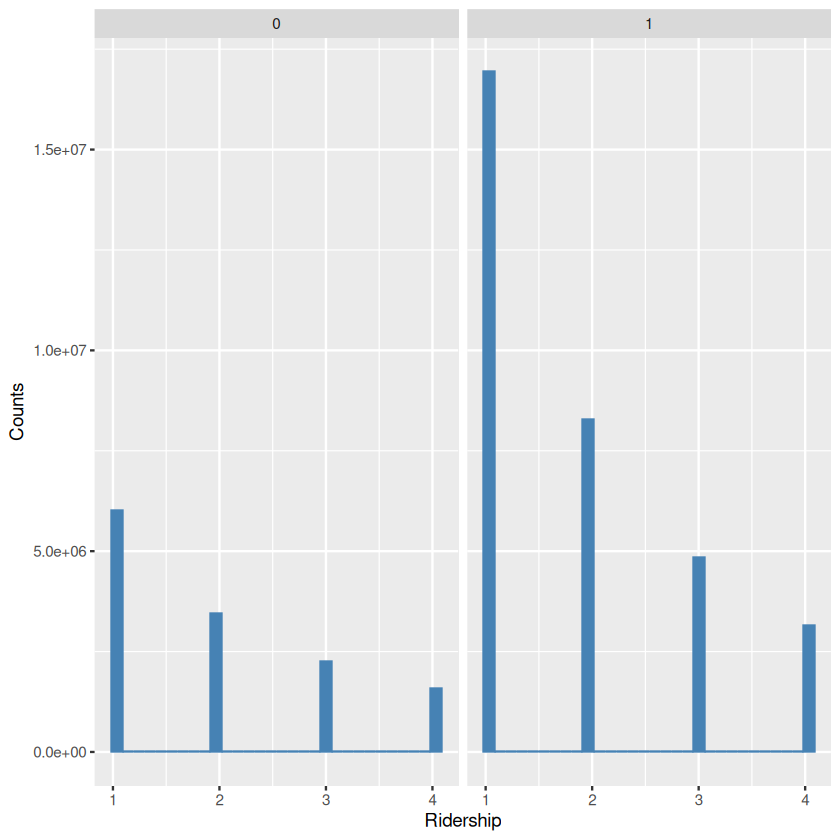

In [29]:
od_data |> 
    filter(ridership %in% c(1, 2, 3, 4)) |>
    ggplot(aes(x = ridership)) + 
        geom_histogram(bins = 30, color = "steelblue", fill = "steelblue") + 
        labs(x = "Ridership",
            y = "Counts") + 
        facet_wrap(~ post_covid)

In [30]:
od_data_filtered <- od_data |>
                filter(!(year(date) %in% c(2020, 2021)) & 
                        !(hour %in% c(1, 2, 3, 4)))

`summarise()` has grouped output by 'day'. You can override using the `.groups`
argument.


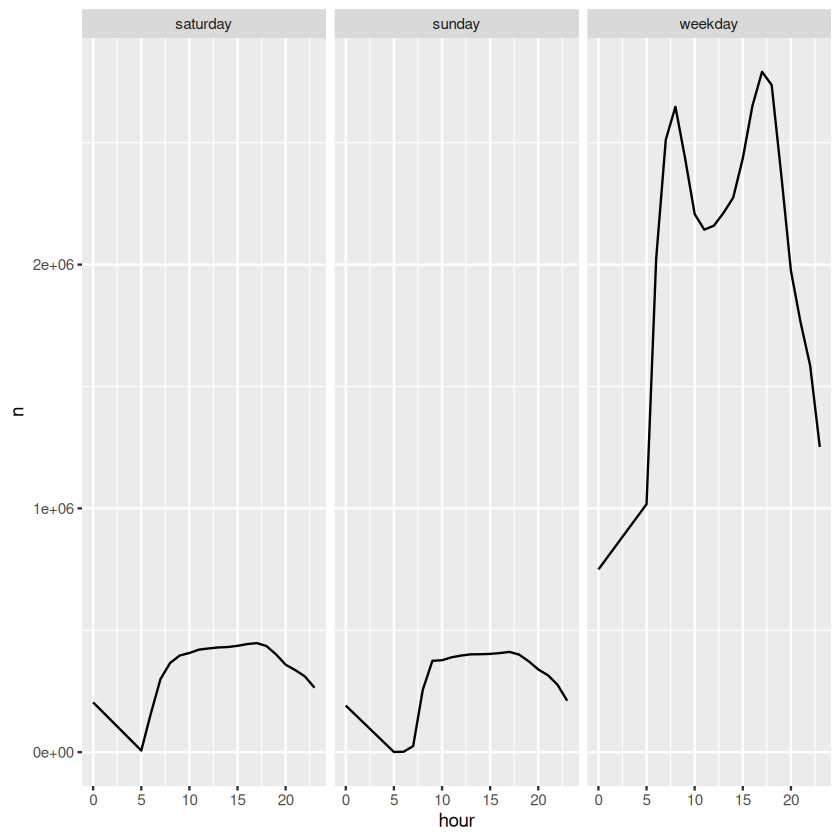

In [37]:
od_data_filtered |>
    group_by(day, hour) |>
    summarize(n = n()) |>
    ggplot(aes(x = hour)) + 
        geom_line(aes(y = n)) + 
        facet_wrap(~ day)

Let's see the size now

In [40]:
format(object.size(od_data_filtered), units = "GB")

[1] "3.3 Gb"

My last comment before I stop is that there are different service hours on weekdays, saturdays, and sundays, so we will need to apply different filtering rules in the future. Additionally, I'm not sure if the service hours have stayed the same from 2018-2025.